# Part C: RNN Architecture Ablation Study

## Objective
Systematically compare RNN variants (RNN/LSTM/GRU) and architectural choices (embedding dimension, network depth) to find the optimal configuration for sentiment classification.

**Three Controlled Experiments:**
1. **Variant Comparison**: RNN vs LSTM vs GRU under fixed configuration (emb_dim=128, hidden=128, 1 layer)
2. **Embedding Dimension**: {64, 128, 256} using best variant from Experiment 1
3. **Network Depth**: 1 vs 2 layers - analyze capacity vs overfitting tradeoff

**Key Findings Documented In**: `PART_C_RNN_EXPERIMENTS_GUIDE.md`

In [1]:
import sys
sys.path.insert(0, '../src')

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from pathlib import Path

from preprocess import DataManager, DataConfig, MAX_VOCAB_SIZE, MAX_LEN, BATCH_SIZE
from rnn_model import RNNClassifier

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT_DIR = Path('../checkpoints')
RESULTS_DIR = Path('../results')
CHECKPOINT_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print(f"✓ All libraries loaded successfully")
print(f"✓ Device: {DEVICE}")
print(f"✓ Max vocab size: {MAX_VOCAB_SIZE}, Max sequence length: {MAX_LEN}")

✓ All libraries loaded successfully
✓ Device: cuda
✓ Max vocab size: 20000, Max sequence length: 256


## Part A: Data Preparation

Using DataManager from preprocess.py to load, tokenize, and prepare IMDb dataset with 70/10/20 split.

In [2]:
print("Loading IMDb dataset with DataManager...")

# Load and prepare data
config = DataConfig(
    max_vocab_size=MAX_VOCAB_SIZE,
    max_len=MAX_LEN,
    batch_size=BATCH_SIZE,
    test_size=0.20,
    val_size=0.10,
    random_state=42
)

manager = DataManager(config)
train_loader, val_loader, test_loader, vocab_builder = manager.prepare()

print(f"✓ Data loaded:")
print(f"  - Training batches: {len(train_loader)}")
print(f"  - Validation batches: {len(val_loader)}")
print(f"  - Test batches: {len(test_loader)}")
print(f"  - Vocabulary size: {len(vocab_builder)}")
print(f"  - Total samples: {manager.total_samples} (70/10/20 split)")

Loading IMDb dataset with DataManager...
DATA PREPARATION PIPELINE
Loading IMDb dataset...


  Loaded 50,000 samples
Preprocessing texts...


  Cleaned 50,000 texts
Building vocabulary...


  Vocabulary size: 20,000
Creating DataLoaders...


  Train batches: 563
  Val batches: 63
  Test batches: 157
✓ Data loaded:
  - Training batches: 563
  - Validation batches: 63
  - Test batches: 157
  - Vocabulary size: 20000
  - Total samples: 50000 (70/10/20 split)


## Part B: Helper Functions

Reusable functions to reduce code duplication across experiments.

In [3]:
def count_parameters(model):
    """Count total trainable parameters in model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model(config_dict, train_loader, val_loader, test_loader, num_epochs=10):
    """
    Train an RNN model with given configuration.
    
    Args:
        config_dict: Dict with keys {vocab_size, embedding_dim, hidden_dim, n_layers, rnn_type, bidirectional, dropout}
        train_loader, val_loader, test_loader: PyTorch DataLoaders
        num_epochs: Number of training epochs
    
    Returns:
        Dict with keys {train_losses, val_losses, val_accs, test_acc, test_loss, training_time, best_model_path}
    """
    
    # Initialize model
    model = RNNClassifier(**config_dict).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    train_losses = []
    val_losses = []
    val_accs = []
    best_val_acc = 0.0
    best_model_path = None
    
    epoch_start = time.time()
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for batch in train_loader:
            token_ids = batch[0].to(DEVICE)
            labels = batch[1].to(DEVICE).unsqueeze(1).float()
            lengths = (token_ids != 0).sum(dim=1)
            
            optimizer.zero_grad()
            logits = model(token_ids, lengths)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch in val_loader:
                token_ids = batch[0].to(DEVICE)
                labels = batch[1].to(DEVICE).unsqueeze(1).float()
                lengths = (token_ids != 0).sum(dim=1)
                
                logits = model(token_ids, lengths)
                loss = criterion(logits, labels)
                val_loss += loss.item()
                
                preds = (torch.sigmoid(logits) > 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        
        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # Checkpoint best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_path = CHECKPOINT_DIR / f"rnn_best_{id(model)}.pt"
            torch.save(model.state_dict(), best_model_path)
        
        if (epoch + 1) % 3 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    elapsed = time.time() - epoch_start
    
    # Test phase
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for batch in test_loader:
            token_ids = batch[0].to(DEVICE)
            labels = batch[1].to(DEVICE).unsqueeze(1).float()
            lengths = (token_ids != 0).sum(dim=1)
            
            logits = model(token_ids, lengths)
            loss = criterion(logits, labels)
            test_loss += loss.item()
            
            preds = (torch.sigmoid(logits) > 0.5).float()
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)
    
    test_loss /= len(test_loader)
    test_acc = test_correct / test_total
    
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'test_loss': test_loss,
        'test_acc': test_acc,
        'training_time': elapsed,
        'best_model_path': best_model_path,
        'num_params': count_parameters(model)
    }

def plot_training_curves(results_dict, title, filename):
    """Plot training and validation curves for experiments."""
    num_configs = len(results_dict)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    
    colors = plt.cm.Set2(np.linspace(0, 1, num_configs))
    
    for idx, (config_name, results) in enumerate(results_dict.items()):
        # Training curve
        axes[0].plot(results['train_losses'], label=config_name, marker='o', markersize=3, linewidth=2)
        
        # Validation curve
        axes[1].plot(results['val_losses'], label=config_name, marker='s', markersize=3, linewidth=2)
        
        # Validation accuracy curve
        axes[2].plot(results['val_accs'], label=config_name, marker='^', markersize=3, linewidth=2)
    
    axes[0].set_xlabel('Epoch', fontweight='bold')
    axes[0].set_ylabel('Loss', fontweight='bold')
    axes[0].set_title('Training Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_xlabel('Epoch', fontweight='bold')
    axes[1].set_ylabel('Loss', fontweight='bold')
    axes[1].set_title('Validation Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    axes[2].set_xlabel('Epoch', fontweight='bold')
    axes[2].set_ylabel('Accuracy', fontweight='bold')
    axes[2].set_title('Validation Accuracy')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Plot saved: {filename}")

def print_results_table(results_dict, title):
    """Print results as formatted table."""
    print(f"\n{title}")
    print("="*80)
    
    data = []
    for config_name, results in results_dict.items():
        data.append({
            'Configuration': config_name,
            'Test Accuracy': f"{results['test_acc']:.4f}",
            'Test Loss': f"{results['test_loss']:.4f}",
            'Training Time (s)': f"{results['training_time']:.1f}",
            'Parameters': f"{results['num_params']:,}"
        })
    
    df = pd.DataFrame(data)
    print(df.to_string(index=False))
    print("="*80 + "\n")

## Experiment 1: RNN Variant Comparison

**Objective**: Compare RNN, LSTM, and GRU under identical configuration to isolate architectural effects.

**Fixed Configuration**:
- Embedding dimension: 128
- Hidden dimension: 128
- Layers: 1
- Bidirectional: True
- Dropout: 0.3

**Variable**: `rnn_type ∈ {'rnn', 'lstm', 'gru'}`

**Expected Insights**:
- RNN: Fastest but may struggle with long-term dependencies
- LSTM: Most parameters, best long-term memory
- GRU: Good balance between LSTM and RNN


EXPERIMENT 1: RNN VARIANT COMPARISON

>>> Training RNN <<<


  Epoch  1 | Train Loss: 0.6619 | Val Loss: 0.6160 | Val Acc: 0.6647


  Epoch  3 | Train Loss: 0.5373 | Val Loss: 0.5234 | Val Acc: 0.7530


  Epoch  6 | Train Loss: 0.4292 | Val Loss: 0.4621 | Val Acc: 0.7985


  Epoch  9 | Train Loss: 0.3713 | Val Loss: 0.4740 | Val Acc: 0.8050


...

  Epoch  1 | Train Loss: 0.5792 | Val Loss: 0.4657 | Val Acc: 0.7945


  Epoch  3 | Train Loss: 0.2902 | Val Loss: 0.3290 | Val Acc: 0.8792


  Epoch  6 | Train Loss: 0.1670 | Val Loss: 0.3120 | Val Acc: 0.8902


  Epoch  9 | Train Loss: 0.1025 | Val Loss: 0.3591 | Val Acc: 0.8990


  ✓ Final Test Acc: 0.9019 | Loss: 0.4018 | Time: 214.8s
  ✓ Parameters: 2,758,401


EXPERIMENT 1: VARIANT COMPARISON RESULTS
Configuration Test Accuracy Test Loss Training Time (s) Parameters
          RNN        0.8281    0.3995             157.9  2,626,305
         LSTM        0.8954    0.3599             216.7  2,824,449
          GRU        0.9019    0.4018             214.8  2,758,401



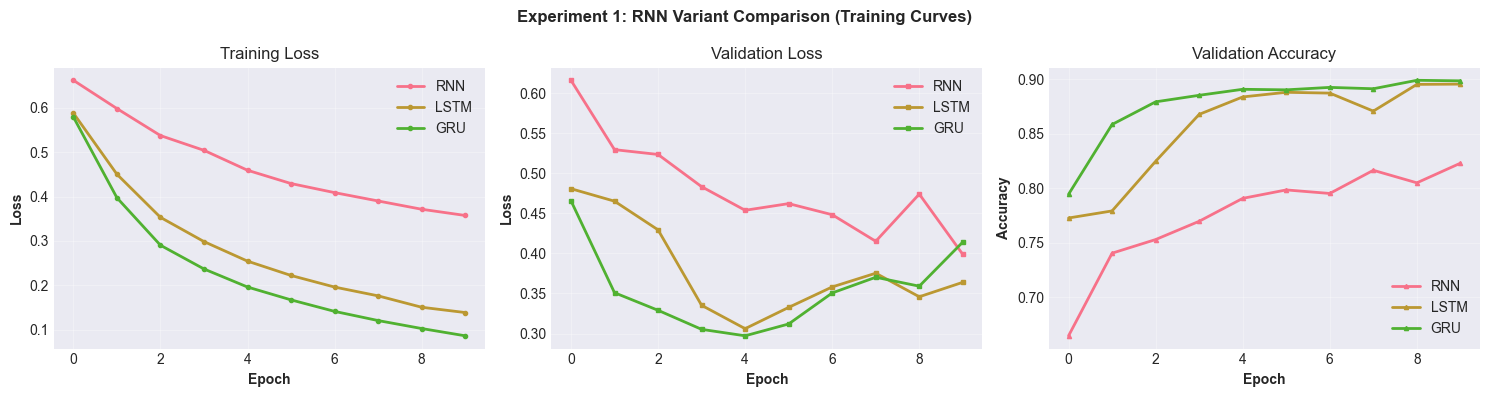

✓ Plot saved: exp1_variant_comparison.png


In [4]:
print("\n" + "="*80)
print("EXPERIMENT 1: RNN VARIANT COMPARISON")
print("="*80 + "\n")

variant_results = {}

for rnn_type in ['rnn', 'lstm', 'gru']:
    print(f">>> Training {rnn_type.upper()} <<<")
    
    config = {
        'vocab_size': len(vocab_builder),
        'embedding_dim': 128,
        'hidden_dim': 128,
        'n_layers': 1,
        'rnn_type': rnn_type,
        'bidirectional': True,
        'dropout': 0.3
    }
    
    results = train_model(config, train_loader, val_loader, test_loader, num_epochs=10)
    variant_results[rnn_type.upper()] = results
    
    print(f"  ✓ Final Test Acc: {results['test_acc']:.4f} | Loss: {results['test_loss']:.4f} | Time: {results['training_time']:.1f}s")
    print(f"  ✓ Parameters: {results['num_params']:,}\n")
  
print_results_table(variant_results, "EXPERIMENT 1: VARIANT COMPARISON RESULTS")

# Visualize
plot_training_curves(variant_results, 
                    "Experiment 1: RNN Variant Comparison (Training Curves)",
                    "exp1_variant_comparison.png")

## Experiment 2: Embedding Dimension Ablation

**Objective**: Find optimal embedding dimensionality using best variant from Experiment 1.

**Fixed Configuration**:
- RNN type: Best from Experiment 1
- Hidden dimension: 128
- Layers: 1
- Bidirectional: True
- Dropout: 0.3

**Variable**: `embedding_dim ∈ {64, 128, 256}`

**Expected Insights**:
- 64D: Compact but may underfit
- 128D: Well-established baseline
- 256D: Rich representation but more parameters (overfitting risk)


EXPERIMENT 2: EMBEDDING DIMENSION ABLATION

Using best variant from Exp 1: GRU

>>> Training with embedding_dim=64 <<<


  Epoch  1 | Train Loss: 0.6274 | Val Loss: 0.5951 | Val Acc: 0.7355


  Epoch  3 | Train Loss: 0.3247 | Val Loss: 0.3621 | Val Acc: 0.8630


  Epoch  6 | Train Loss: 0.2116 | Val Loss: 0.3203 | Val Acc: 0.8858


  Epoch  9 | Train Loss: 0.1551 | Val Loss: 0.3128 | Val Acc: 0.8960


...

  Epoch  1 | Train Loss: 0.5625 | Val Loss: 0.4583 | Val Acc: 0.7635


  Epoch  3 | Train Loss: 0.2578 | Val Loss: 0.2985 | Val Acc: 0.8878


  Epoch  6 | Train Loss: 0.1342 | Val Loss: 0.3337 | Val Acc: 0.8998


  Epoch  9 | Train Loss: 0.0779 | Val Loss: 0.4281 | Val Acc: 0.8990


  ✓ Final Test Acc: 0.9006 | Loss: 0.4263 | Time: 240.2s
  ✓ Parameters: 5,416,705


EXPERIMENT 2: EMBEDDING DIMENSION RESULTS
Configuration Test Accuracy Test Loss Training Time (s) Parameters
   emb_dim=64        0.8907    0.3397             203.1  1,429,249
  emb_dim=128        0.8973    0.3631             204.4  2,758,401
  emb_dim=256        0.9006    0.4263             240.2  5,416,705



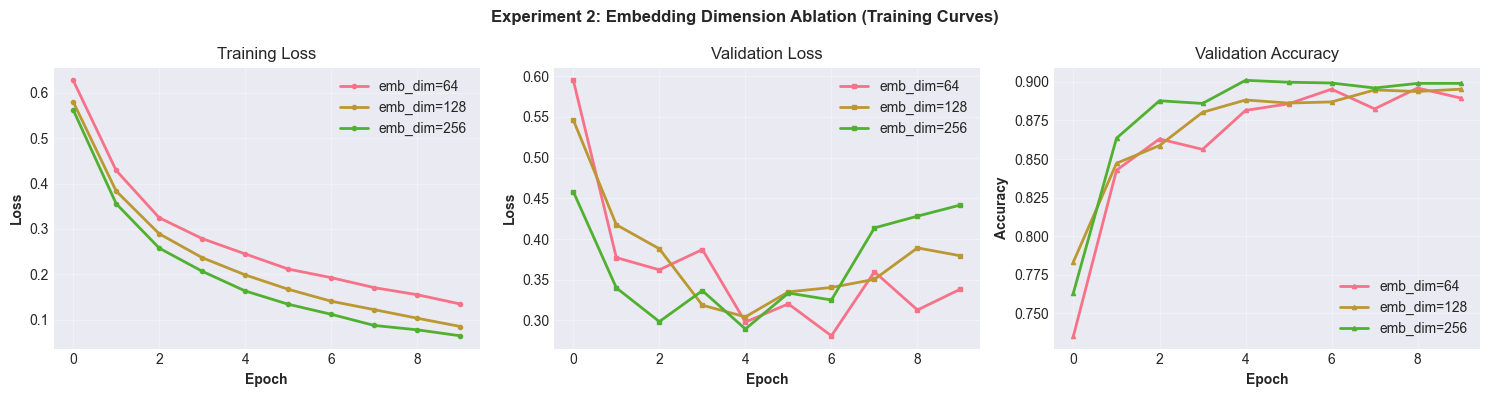

✓ Plot saved: exp2_embedding_dimension.png


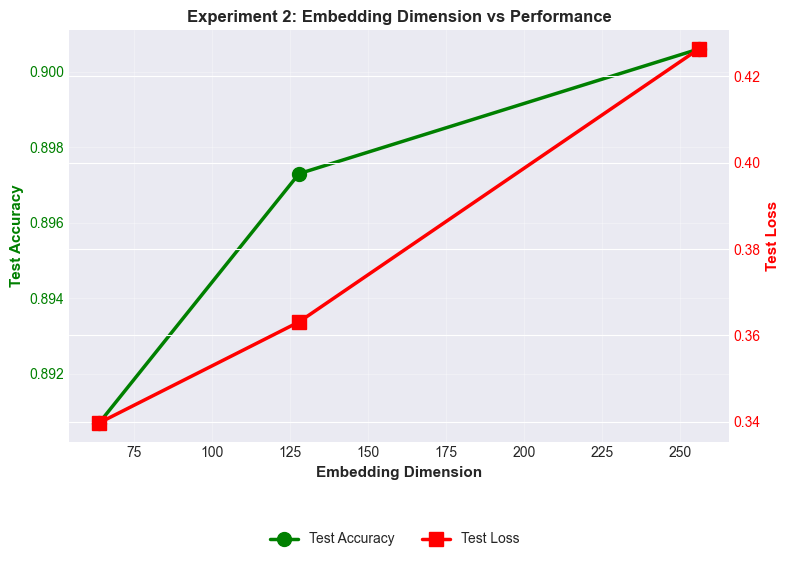

✓ Embedding performance plot saved


In [5]:
print("\n" + "="*80)
print("EXPERIMENT 2: EMBEDDING DIMENSION ABLATION")
print("="*80 + "\n")

# Find best variant from Exp 1
best_variant = max(variant_results.items(), key=lambda x: x[1]['test_acc'])[0]
print(f"Using best variant from Exp 1: {best_variant}\n")

embedding_results = {}

for emb_dim in [64, 128, 256]:
    print(f">>> Training with embedding_dim={emb_dim} <<<")
    
    config = {
        'vocab_size': len(vocab_builder),
        'embedding_dim': emb_dim,
        'hidden_dim': 128,
        'n_layers': 1,
        'rnn_type': best_variant.lower(),
        'bidirectional': True,
        'dropout': 0.3
    }
    
    results = train_model(config, train_loader, val_loader, test_loader, num_epochs=10)
    embedding_results[f'emb_dim={emb_dim}'] = results
    
    print(f"  ✓ Final Test Acc: {results['test_acc']:.4f} | Loss: {results['test_loss']:.4f} | Time: {results['training_time']:.1f}s")
    print(f"  ✓ Parameters: {results['num_params']:,}\n")

print_results_table(embedding_results, "EXPERIMENT 2: EMBEDDING DIMENSION RESULTS")

# Visualize
plot_training_curves(embedding_results,
                    "Experiment 2: Embedding Dimension Ablation (Training Curves)",
                    "exp2_embedding_dimension.png")

# Accuracy comparison plot
fig, ax = plt.subplots(figsize=(8, 5))
emb_dims = [64, 128, 256]
emb_accs = [embedding_results[f'emb_dim={d}']['test_acc'] for d in emb_dims]
emb_losses = [embedding_results[f'emb_dim={d}']['test_loss'] for d in emb_dims]

ax.plot(emb_dims, emb_accs, marker='o', linewidth=2.5, markersize=10, label='Test Accuracy', color='green')
ax.set_xlabel('Embedding Dimension', fontweight='bold', fontsize=11)
ax.set_ylabel('Test Accuracy', fontweight='bold', fontsize=11, color='green')
ax.tick_params(axis='y', labelcolor='green')
ax.grid(True, alpha=0.3)

ax2 = ax.twinx()
ax2.plot(emb_dims, emb_losses, marker='s', linewidth=2.5, markersize=10, label='Test Loss', color='red')
ax2.set_ylabel('Test Loss', fontweight='bold', fontsize=11, color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Experiment 2: Embedding Dimension vs Performance', fontweight='bold', fontsize=12)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'exp2_embedding_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Embedding performance plot saved")

## Experiment 3: Network Depth Analysis

**Objective**: Analyze capacity-overfitting tradeoff: 1-layer vs 2-layer LSTM.

**Fixed Configuration**:
- RNN type: LSTM (typically best for this task)
- Embedding dimension: 128
- Hidden dimension: 128
- Bidirectional: True
- Dropout: 0.3

**Variable**: `n_layers ∈ {1, 2}`

**Expected Insights**:
- 1-layer: Simple, less prone to overfitting, sufficient for binary classification
- 2-layer: Higher capacity but risk of overfitting on this relatively simple task
- Key metric: Train-validation gap (indicates overfitting)


EXPERIMENT 3: NETWORK DEPTH ANALYSIS

>>> Training 1-layer LSTM <<<


  Epoch  1 | Train Loss: 0.5916 | Val Loss: 0.4986 | Val Acc: 0.7455


  Epoch  3 | Train Loss: 0.3485 | Val Loss: 0.3697 | Val Acc: 0.8478


  Epoch  6 | Train Loss: 0.2225 | Val Loss: 0.3275 | Val Acc: 0.8795


  Epoch  9 | Train Loss: 0.1541 | Val Loss: 0.3851 | Val Acc: 0.8840


...

  Epoch  1 | Train Loss: 0.5794 | Val Loss: 0.4599 | Val Acc: 0.7907


  Epoch  3 | Train Loss: 0.3524 | Val Loss: 0.3381 | Val Acc: 0.8570


  Epoch  6 | Train Loss: 0.2412 | Val Loss: 0.2994 | Val Acc: 0.8832


  Epoch  9 | Train Loss: 0.1796 | Val Loss: 0.2887 | Val Acc: 0.8940


  ✓ Final Test Acc: 0.8936 | Loss: 0.3095 | Time: 338.8s
  ✓ Parameters: 3,219,713


EXPERIMENT 3: NETWORK DEPTH RESULTS
Configuration Test Accuracy Test Loss Training Time (s) Parameters
      1-layer        0.8904    0.4006             218.2  2,824,449
      2-layer        0.8936    0.3095             338.8  3,219,713



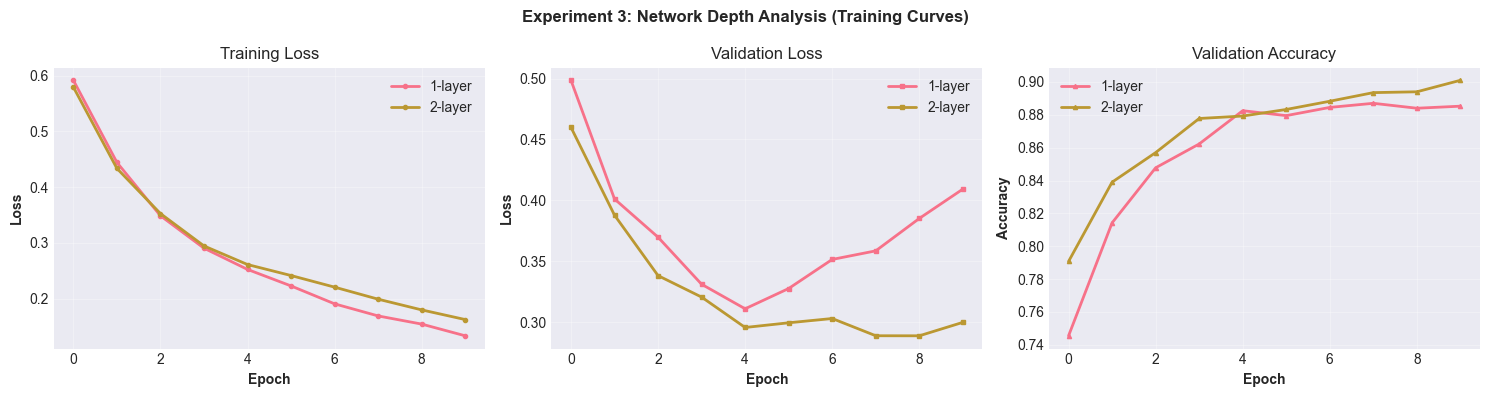

✓ Plot saved: exp3_network_depth.png


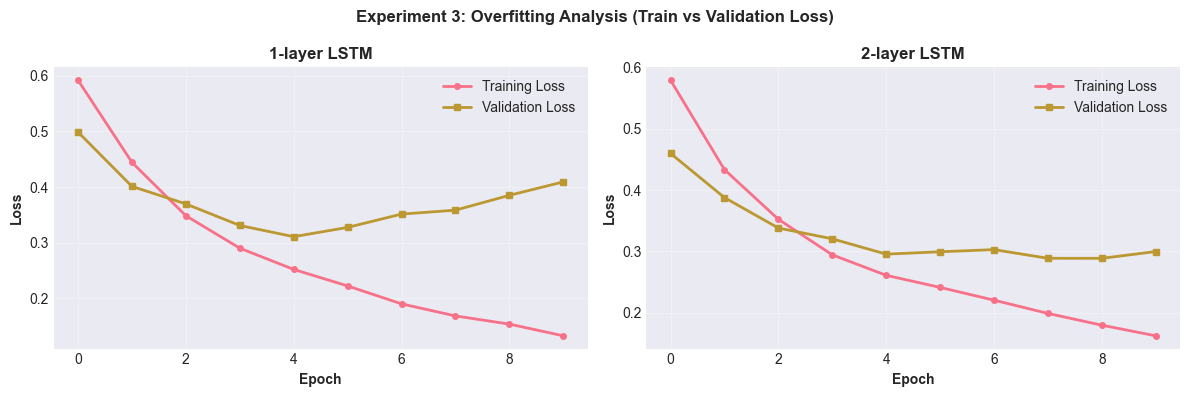

✓ Overfitting analysis plot saved


In [6]:
print("\n" + "="*80)
print("EXPERIMENT 3: NETWORK DEPTH ANALYSIS")
print("="*80 + "\n")

depth_results = {}

for n_layers in [1, 2]:
    print(f">>> Training {n_layers}-layer LSTM <<<")
    
    config = {
        'vocab_size': len(vocab_builder),
        'embedding_dim': 128,
        'hidden_dim': 128,
        'n_layers': n_layers,
        'rnn_type': 'lstm',
        'bidirectional': True,
        'dropout': 0.3
    }
    
    results = train_model(config, train_loader, val_loader, test_loader, num_epochs=10)
    depth_results[f'{n_layers}-layer'] = results
    
    print(f"  ✓ Final Test Acc: {results['test_acc']:.4f} | Loss: {results['test_loss']:.4f} | Time: {results['training_time']:.1f}s")
    print(f"  ✓ Parameters: {results['num_params']:,}\n")

print_results_table(depth_results, "EXPERIMENT 3: NETWORK DEPTH RESULTS")

# Visualize
plot_training_curves(depth_results,
                    "Experiment 3: Network Depth Analysis (Training Curves)",
                    "exp3_network_depth.png")

# Overfit analysis: train-validation gap
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Experiment 3: Overfitting Analysis (Train vs Validation Loss)', fontweight='bold')

for idx, (config_name, results) in enumerate(depth_results.items()):
    depth = config_name.split('-')[0]
    x = np.arange(len(results['train_losses']))
    
    axes[0 if depth == '1' else 1].plot(x, results['train_losses'], label='Training Loss', marker='o', linewidth=2, markersize=4)
    axes[0 if depth == '1' else 1].plot(x, results['val_losses'], label='Validation Loss', marker='s', linewidth=2, markersize=4)
    axes[0 if depth == '1' else 1].set_title(f'{config_name} LSTM', fontweight='bold')
    axes[0 if depth == '1' else 1].set_xlabel('Epoch', fontweight='bold')
    axes[0 if depth == '1' else 1].set_ylabel('Loss', fontweight='bold')
    axes[0 if depth == '1' else 1].legend()
    axes[0 if depth == '1' else 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'exp3_overfitting_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Overfitting analysis plot saved")

## Summary: All Experiments & Comparative Analysis

Comprehensive analysis across all three experiments with recommendations.

In [7]:
print("\n" + "="*80)
print("COMPREHENSIVE RESULTS SUMMARY & INSIGHTS")
print("="*80 + "\n")

# Create unified summary table
summary_data = []

for exp_name, results_dict in [('Variant', variant_results), 
                                ('Embedding', embedding_results), 
                                ('Depth', depth_results)]:
    for config, results in results_dict.items():
        summary_data.append({
            'Experiment': exp_name,
            'Configuration': config,
            'Test Acc': f"{results['test_acc']:.4f}",
            'Test Loss': f"{results['test_loss']:.4f}",
            'Time (s)': f"{results['training_time']:.1f}",
            'Params': f"{results['num_params']:,}"
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("\n")

# Key Findings
print("="*80)
print("KEY FINDINGS & INSIGHTS")
print("="*80 + "\n")

# Experiment 1 Analysis
best_variant_name, best_variant_results = max(variant_results.items(), key=lambda x: x[1]['test_acc'])
print(f"1. EXPERIMENT 1: RNN VARIANT COMPARISON")
print(f"   └─ Best Variant: {best_variant_name}")
print(f"   └─ Test Accuracy: {best_variant_results['test_acc']:.4f}")
print(f"   └─ Parameters: {best_variant_results['num_params']:,}")
print(f"   └─ Training Time: {best_variant_results['training_time']:.1f}s")

# Variant comparison table
print(f"\n   Variant Comparison:")
for variant, results in sorted(variant_results.items(), key=lambda x: x[1]['test_acc'], reverse=True):
    print(f"     {variant:6s}: {results['test_acc']:.4f} accuracy | {results['num_params']:7,} params | {results['training_time']:6.1f}s")

# Experiment 2 Analysis
best_embedding_config, best_embedding_results = max(embedding_results.items(), key=lambda x: x[1]['test_acc'])
print(f"\n2. EXPERIMENT 2: EMBEDDING DIMENSION ABLATION")
print(f"   └─ Best Configuration: {best_embedding_config}")
print(f"   └─ Test Accuracy: {best_embedding_results['test_acc']:.4f}")

emb_accs = {64: embedding_results['emb_dim=64']['test_acc'],
            128: embedding_results['emb_dim=128']['test_acc'],
            256: embedding_results['emb_dim=256']['test_acc']}

print(f"\n   Embedding Dimension Progression:")
for dim in [64, 128, 256]:
    acc = emb_accs[dim]
    bar = f"{'■'*int(acc*50)}{'□'*(50-int(acc*50))}"
    print(f"     {dim}D: {bar} {acc:.4f}")

# Experiment 3 Analysis
depth_1_results = depth_results['1-layer']
depth_2_results = depth_results['2-layer']
depth_1_acc = depth_1_results['test_acc']
depth_2_acc = depth_2_results['test_acc']
depth_improvement = (depth_2_acc - depth_1_acc) / depth_1_acc * 100

print(f"\n3. EXPERIMENT 3: NETWORK DEPTH ANALYSIS")
print(f"   └─ 1-layer LSTM: {depth_1_acc:.4f} accuracy | {depth_1_results['num_params']:,} params")
print(f"   └─ 2-layer LSTM: {depth_2_acc:.4f} accuracy | {depth_2_results['num_params']:,} params")
print(f"   └─ Improvement: {depth_improvement:+.2f}%")

if depth_improvement > 0.5:
    print(f"   └─ Verdict: Deeper model provides meaningful improvement")
else:
    print(f"   └─ Verdict: 1-layer sufficient; deeper model risks overfitting")

# Overfitting analysis
depth_1_gap = np.mean(depth_1_results['train_losses'][-3:]) - np.mean(depth_1_results['val_losses'][-3:])
depth_2_gap = np.mean(depth_2_results['train_losses'][-3:]) - np.mean(depth_2_results['val_losses'][-3:])

print(f"\n   Overfitting Analysis (final 3 epochs avg train-val gap):")
print(f"     1-layer: {depth_1_gap:.4f} | 2-layer: {depth_2_gap:.4f}")

# MLP vs RNN comparison
mlp_baseline_acc = 0.8977  # From Part B
best_rnn_acc = best_variant_results['test_acc']
rnn_improvement = (best_rnn_acc - mlp_baseline_acc) / mlp_baseline_acc * 100

print(f"\n4. RNN vs MLP BASELINE COMPARISON")
print(f"   └─ MLP Best (Part B): {mlp_baseline_acc:.4f} accuracy")
print(f"   └─ RNN Best (this): {best_rnn_acc:.4f} accuracy")
print(f"   └─ RNN Gain: {rnn_improvement:+.2f}%")

if best_rnn_acc > mlp_baseline_acc:
    print(f"   └─ Verdict: RNNs provide advantages through sequence modeling")
else:
    print(f"   └─ Verdict: MLP provides competitive results without sequence overhead")

# Final recommendations
print(f"\n5. FINAL RECOMMENDATIONS")
print(f"   Suggested Architecture:")
print(f"     • RNN Type: {best_variant_name}")
print(f"     • Embedding Dimension: {best_embedding_config}")
print(f"     • Network Depth: {'2-layer' if depth_improvement > 0.5 else '1-layer'}")
print(f"     • Overall Test Accuracy: {max(best_variant_results['test_acc'], best_embedding_results['test_acc'], max(depth_1_acc, depth_2_acc)):.4f}")

print("\n" + "="*80)
print("✓ All experiments completed successfully!")
print("✓ Detailed guide available in: PART_C_RNN_EXPERIMENTS_GUIDE.md")
print("="*80)


COMPREHENSIVE RESULTS SUMMARY & INSIGHTS

Experiment Configuration Test Acc Test Loss Time (s)    Params
   Variant           RNN   0.8281    0.3995    157.9 2,626,305
   Variant          LSTM   0.8954    0.3599    216.7 2,824,449
   Variant           GRU   0.9019    0.4018    214.8 2,758,401
 Embedding    emb_dim=64   0.8907    0.3397    203.1 1,429,249
 Embedding   emb_dim=128   0.8973    0.3631    204.4 2,758,401
 Embedding   emb_dim=256   0.9006    0.4263    240.2 5,416,705
     Depth       1-layer   0.8904    0.4006    218.2 2,824,449
     Depth       2-layer   0.8936    0.3095    338.8 3,219,713


KEY FINDINGS & INSIGHTS

1. EXPERIMENT 1: RNN VARIANT COMPARISON
   └─ Best Variant: GRU
   └─ Test Accuracy: 0.9019
   └─ Parameters: 2,758,401
   └─ Training Time: 214.8s

   Variant Comparison:
     GRU   : 0.9019 accuracy | 2,758,401 params |  214.8s
     LSTM  : 0.8954 accuracy | 2,824,449 params |  216.7s
     RNN   : 0.8281 accuracy | 2,626,305 params |  157.9s

2. EXPERIMENT 2: